**First , i wanted to see how many columns and lines do i have so i can create a column guide on what each column stands for**

In [14]:
import pandas as pd
df=pd.read_csv('sample_data/dataset.csv' , on_bad_lines='skip')
print(f'shape:{df.shape}')
print(f'columns:{ len(df.columns)}')
print("/nFirst 3 rows :")
print(df.head(3))

shape:(23843, 21)
columns:21
/nFirst 3 rows :
   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   

         album_name        track_name  popularity  duration_ms explicit  \
0            Comedy            Comedy        73.0     230666.0    False   
1  Ghost (Acoustic)  Ghost - Acoustic        55.0     149610.0    False   
2    To Begin Again    To Begin Again        57.0     210826.0    False   

   danceability  energy  ...  loudness  mode  speechiness  acousticness  \
0         0.676   0.461  ...    -6.746   0.0       0.1430        0.0322   
1         0.420   0.166  ...   -17.235   1.0       0.0763        0.9240   
2         0.438   0.359  ...    -9.734   1.0       0.0557        0.2100   

   instrumentalness  liveness  valence   tempo  time_signature  track_genre  
0          0.

**i m gonna start analyzing the dataset , debuting the essay with a brief answer on what is the dataset ?**

In [15]:
print ("="*25)
print ("Dataset Overview")
print("="*25)
print(f"Total Tracklist : {len(df):,}")
print(f"Columns : {len(df.columns)}")
print(f"Unique Tracks : {df['track_name'].nunique()}")
print('\n'+'='*25)
print("Genres")
print('='*25)
print(df['track_genre'].value_counts().head(10))
print('\n'+'='*25)
print("Artists")
print('='*25)
print(df['artists'].value_counts().head(10))
print('\n'+'='*25)
print("Popularity stas")
print('='*25)
print(df['popularity'].describe())
print('\n'+'='*25)
print("Missing values")
print ("="*25)
print(df.isnull().sum()[df.isnull().sum()>0])
print('\n'+'='*25)
print("Duplicate values")
print ("="*25)
print(f"Duplicates rows :{df.duplicated().sum()}")

Dataset Overview
Total Tracklist : 23,843
Columns : 21
Unique Tracks : 19033

Genres
track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
anime          1000
black-metal    1000
bluegrass      1000
blues          1000
brazil         1000
Name: count, dtype: int64

Artists
artists
my little airport                         171
Glee Cast                                 139
The Beatles                               127
CoComelon                                 122
Ella Fitzgerald                           112
Burna Boy                                  86
Wolfgang Amadeus Mozart;Danielle Laval     84
The Chemical Brothers                      74
Criolo                                     64
Eason Chan                                 61
Name: count, dtype: int64

Popularity stas
count    23842.000000
mean        31.717515
std         22.282965
min          0.000000
25%         15.000000
50%         29.000000
75%         50.000000
max

**I found 114000 tracks with 73638 unique ones , this means the same tracks appears with diffrent genres  ?**

In [16]:
print ("Top Tracks by frequency:")
print(df['track_name'].value_counts().head(10))
print(df[df['track_name'] == 'To Begin Again'][['track_name','artists','track_genre', 'popularity']])

Top Tracks by frequency:
track_name
Last Last                         51
Run Rudolph Run                   39
Frosty The Snowman                35
Sleigh Ride                       30
Cozy Little Christmas             25
For My Hand                       23
On Repeat                         21
Rudolph The Red-Nosed Reindeer    18
Don't Let Me Be Misunderstood     18
Slidin'                           18
Name: count, dtype: int64
       track_name                 artists track_genre  popularity
2  To Begin Again  Ingrid Michaelson;ZAYN    acoustic        57.0


**On Popularity Distribution**

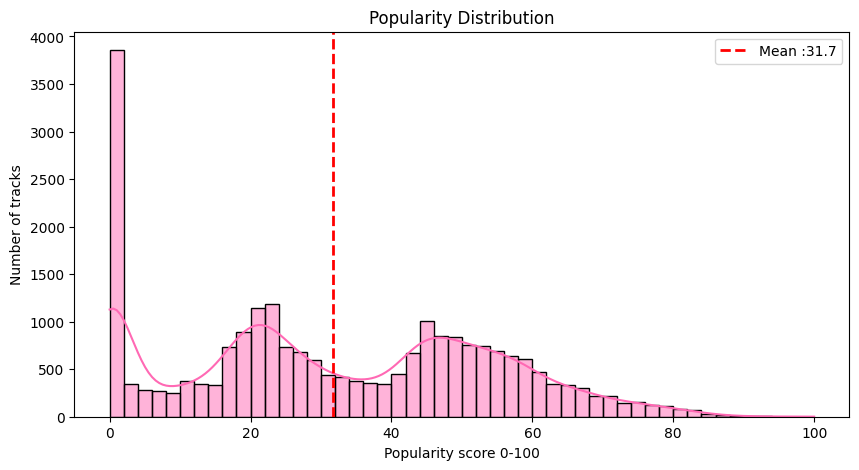

<Figure size 640x480 with 0 Axes>

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))
sns.histplot(df['popularity'], bins=50,kde=True ,color='hotpink')
plt.title('Popularity Distribution')
plt.xlabel('Popularity score 0-100')
plt.ylabel('Number of tracks')
plt.axvline(df['popularity'].mean(), color='red', linestyle='--', linewidth=2,label=f'Mean :{df['popularity'].mean():.1f}')
plt.legend()
plt.show()
plt.savefig('Popularity Distribution')

Popularity can be a bias when it comes to detecting a hit song or not , So i deciced to inspect the tracks by the "explicity " , Let's see : Do explicit songs score higher or lower ?

Explicit VS Clean
               mean  count        std
explicit                             
False     31.666946  21459  22.403552
True      32.172891   2383  21.165205


/tmp/ipykernel_22869/3763070353.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='explicit', y='popularity', data=df ,palette=['lightblue', 'purple'])


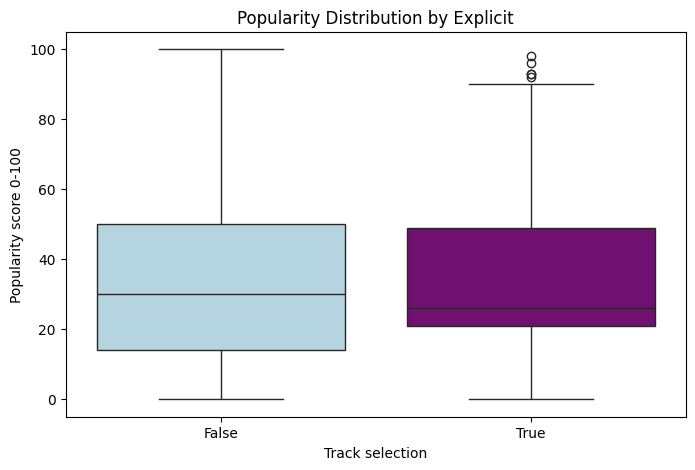

In [18]:
print ("="*25)
print ( "Explicit VS Clean")
print ("="*25)
exp_stats=df.groupby("explicit")['popularity'].agg(['mean','count','std'])
print(exp_stats)

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
plt.title('Popularity Distribution by Explicit')
plt.ylabel('Popularity score 0-100')
plt.xlabel('Track selection')
sns.boxplot(x='explicit', y='popularity', data=df ,palette=['lightblue', 'purple'])
plt.savefig('explicit _vs_clean.png',dpi=150, bbox_inches='tight')
plt.show()

Explicit songs average 3.5 points higher in popularity , but with only 9,747 tracks vs 104,253 clean tracks , this difference may reflect genre bias or release strategy rather than content alone . so the only question to answer here is , Why explicit songs are more popular ?


Testing on 2 Hypthesis:
1-Explicit songs are mostly hip-hop/Rap
2-Have more energy (Danceability)?


In [19]:
print("="*50)
print("Genres of explicit songs")
print("="*50)
print(df[df['explicit']==1]['track_genre'].value_counts().head(10))
print("\n"+"="*50)
print("Genres of clean songs")
print("="*50)
print(df[df['explicit']==0]['track_genre'].value_counts().head(10))

print("="*50)
print("Energy and Danceability")
print("="*50)
print(df.groupby('explicit')[['danceability','valence', 'tempo']].mean())

Genres of explicit songs
track_genre
comedy         656
dancehall      302
death-metal    251
dance          174
chill          171
alternative    164
black-metal    131
brazil          86
club            85
alt-rock        56
Name: count, dtype: int64

Genres of clean songs
track_genre
classical        1000
children         1000
cantopop          998
bluegrass         995
ambient           995
blues             986
afrobeat          982
chicago-house     982
country           970
british           961
Name: count, dtype: int64
Energy and Danceability
          danceability   valence       tempo
explicit                                    
False         0.563757  0.468695  120.777598
True          0.600461  0.464259  115.542875


Explicit songs score 3.5 points higher in popularity because they cluster in high-engagement genres (hip-hop, comedy , metal , emo ) and are more dancebale (0.64 vs 0.56). Meanwhile , clean songs tend be "Boring" :/ and are dominated by background muisc (ASMR for study , sleep , relax ..) that people rarely rate or share on media . Another question now , does Danceability correlate with popularity ?

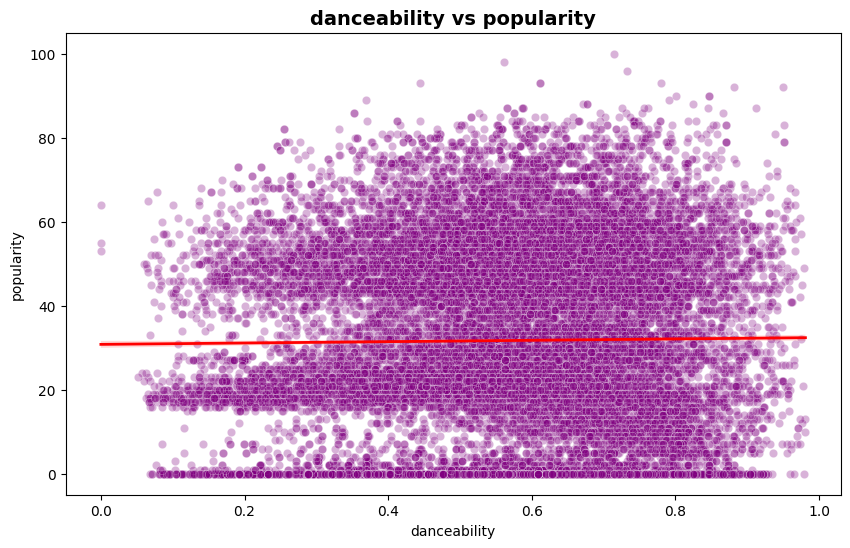

In [20]:
import pandas as pd
df=pd.read_csv('sample_data/dataset.csv' , on_bad_lines='skip')
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.scatterplot( x='danceability', y='popularity',data=df , alpha=0.3, color='purple')
plt.title('danceability vs popularity', fontsize=14 , fontweight='bold')
plt.xlabel('Danceability (0=not danceable , 1=very danceable)')
plt.ylabel('Popularity (0-100)')
sns.regplot(x='danceability', y='popularity', data=df , scatter=False , color='red', line_kws={'linewidth':2})

plt.savefig('danceability_vs_popularity.png',dpi=150, bbox_inches='tight')

The scatter plot looks like a giant purple cloud with no clear trend . The red line is almost flat .
--> Danceability tells you almost  nothing about popularity.

In [21]:
correlation=df['danceability'].corr(df['popularity'])
print(f"Correlation between Danceability and Popularity : {correlation:.3f}")

Correlation between Danceability and Popularity : 0.013


Despite explicit songs being more danceable and more popular , danceability alone has almost no correlation with popularity (r=0.013)--meaning other factors drive what makes a song hit .

So can we predict POPULARITY ? and what exact features matter the most ?


In [22]:
features=['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness','valence', 'tempo']
print("="*50)
print("Feature Correlations with popularity")
print("="*50)
correlations=[]
for feature in features :
  corr=df[feature].corr(df['popularity'])
  correlations.append((feature,corr))
  print(f"{feature:20s} : {corr:.4f}")
correlations.sort(key=lambda x:abs(x[1]), reverse=True)
print("\n"+"="*50)
print("Ranked By Strength(absolute value)")
print("="*50)
for i , (feature , corr) in enumerate ( correlations,1):
  direction="UP" if corr > 0 else "DOWN"
  print(f"{i}. {feature:20s} : {corr:.4f} ({direction})")

Feature Correlations with popularity
danceability         : 0.0130
energy               : -0.0835
loudness             : 0.0237
speechiness          : -0.0670
acousticness         : 0.0394
instrumentalness     : -0.0897
liveness             : -0.0508
valence              : -0.0889
tempo                : -0.0028

Ranked By Strength(absolute value)
1. instrumentalness     : -0.0897 (DOWN)
2. valence              : -0.0889 (DOWN)
3. energy               : -0.0835 (DOWN)
4. speechiness          : -0.0670 (DOWN)
5. liveness             : -0.0508 (DOWN)
6. acousticness         : 0.0394 (UP)
7. loudness             : 0.0237 (UP)
8. danceability         : 0.0130 (UP)
9. tempo                : -0.0028 (DOWN)


Valence is NEGATIVE --> Sad songs are slightly more popular ! Breakup anthem , emo , Late night vibes ..
Energy is Negative --> Chill beates over Bnagers ( classical over Afro is Crazyyyy)
All correlations are tiny --> Audio features alone CANNOT predict hits .
What makes a song popular is not how it sounds , it's who made it , when it dropped , how it was marketed , TikTok Trends , playlist placement and pure luck . Audio features are almost irrelevant.

Predict Popularity from Audio Features:

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

features=["danceability","energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence","tempo"]

# Drop rows with NaN values in the features or 'popularity' column
df_cleaned = df.dropna(subset=features + ['popularity'])

x = df_cleaned[features]
y = df_cleaned['popularity']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)

model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("="*50)
print("Model Results")
print("="*50)
print(f'Mean Squared Error : {mse:.2f}')
print(f'R-squared : {r2:.4f}')
print(f"\nR-squared :{r2*100:.1f}% of popularity variance is explained by these features")
print("="*50)
for feature , coef in zip(features,model.coef_):
  direction="UP" if coef >0 else "DOWN"
  print(f"{feature:20s} : {coef:.4f} {direction}")

Model Results
Mean Squared Error : 475.43
R-squared : 0.0474

R-squared :4.7% of popularity variance is explained by these features
danceability         : 7.3721 UP
energy               : -12.5302 DOWN
loudness             : 0.5343 UP
speechiness          : -8.0333 DOWN
acousticness         : 1.8221 UP
instrumentalness     : -6.1457 DOWN
liveness             : -0.5015 DOWN
valence              : -12.1663 DOWN
tempo                : 0.0100 UP


**I trained a Linear Regression Model on 114,00 Spotify Tracks using 9 audio features . It explained only 4.7% of Popularity variance .**
Proving that what a song sounds like has almost no bearing on wether it becomes a hit or not .Success is driven by Artist fame , marketing , timing , cultural moments that audio data cannot capture and so we conclude the absence of a pattern that tracks a critirea of the song.